<a href="https://colab.research.google.com/github/issacridhin/LabWorks/blob/LLM/2348546_LLM_CIA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**First Question - Implement Positional Encoding**

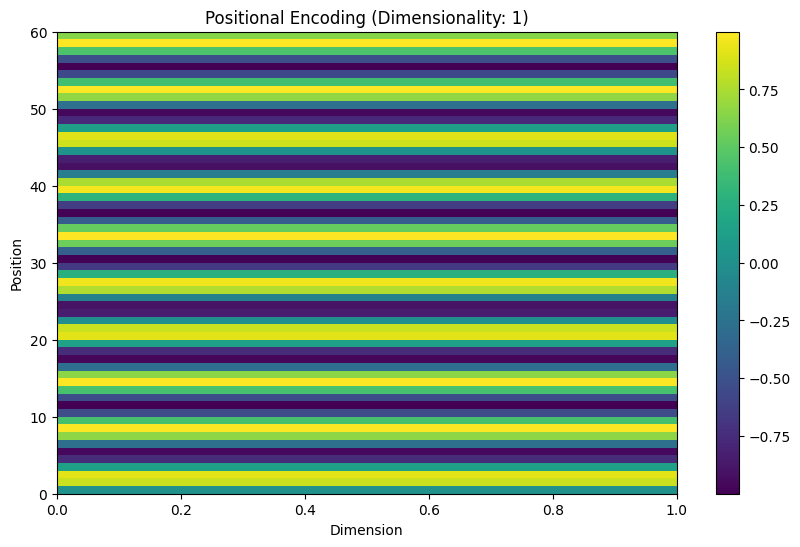

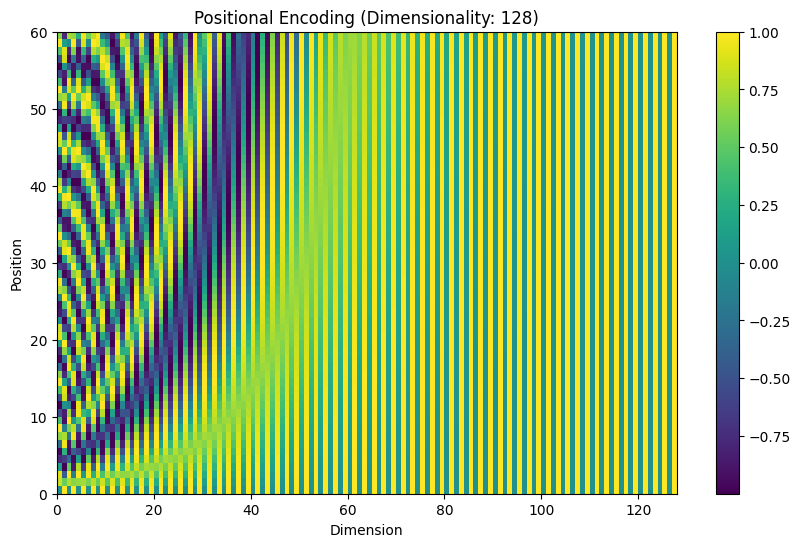

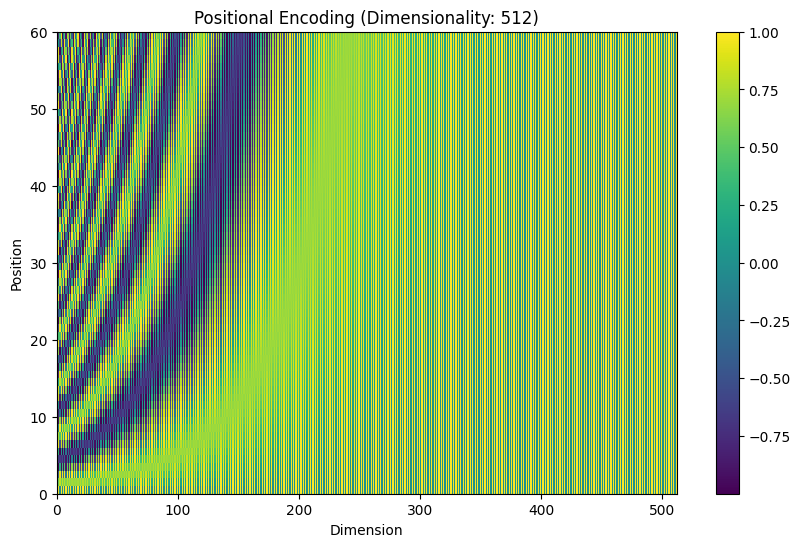

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter Initialization
max_position = 60
dimensions = [1, 128, 512]

def positionalEncoding(max_position, dimensions):
    pos = np.arange(max_position)[:, np.newaxis]
    i = np.arange(dimensions)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(dimensions))
    angle_rads = pos * angle_rates

    # applying sin to only even indices 2i
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # applying cos to only odd indices 2i+1
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return angle_rads

def plot_positional_encoding(positionalEncoding, dimensions):
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(positionalEncoding, cmap='viridis')
    plt.ylabel('Position')
    plt.xlabel('Dimension')
    plt.colorbar()
    plt.title(f'Positional Encoding (Dimensionality: {dimensions})')
    plt.show()

# Plotting positional encodings for different dimensionalities
for dimensions in dimensions:
    pos_encoding = positionalEncoding(max_position, dimensions)
    plot_positional_encoding(pos_encoding, dimensions)

**Second Question - Implement Natural Language Generation**

In [ ]:
!pip install langchain #This library is a framework for developing applications used by Lang Models.
!pip install langchain-groq #langchain-groq is used to interact with the Groq database.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.0/990.0 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.5/373.5 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.1/141.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.5/103.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 5.3 MB/s eta 0:00:00


In [ ]:
#Importing Packages
from langchain_core.output_parsers import StrOutputParser #This class is used to parse the output of a language model into a string.
from langchain_groq import ChatGroq #This class helps us to interacting with a Groq database using a chat-based interface.
from langchain.prompts import PromptTemplate #Used to define a prompt that can be used to generate text from a language model.
import os #Used to perform tasks such as read and write files, creating directories, environment variables, etc.

In [ ]:
#Assigning the API Key from the Groq Cloud website
api_key = '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'
print(api_key)

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


In [29]:
#We initiliazed a Chatgroq object for communication with the database. API key is used for authentication for allowing access to the database.
#We used the gemma2-9b-it lang model for generating the text.
model = ChatGroq(api_key = api_key ,model_name = 'gemma2-9b-it')

In [49]:
parser = StrOutputParser() #parser is used to extract the string output from the model response.
chain = model | parser #The chain helps connect the Model to the Parser. The output of the model will then be passed to the parser.
chain.invoke('What is a perfect relationship') #We are sending the Prompt to the model through the chain and to generate a response. Which is further processed by the parser.

'There\'s no single answer to what makes a "perfect" relationship because perfection is subjective and varies greatly from person to person. What feels perfect for one couple might not feel the same for another. \n\nHowever, some common elements often associated with healthy and fulfilling relationships include:\n\n**Communication:**\n\n* **Open and honest:** Partners feel comfortable sharing their thoughts, feelings, needs, and concerns with each other.\n* **Active listening:** Partners genuinely listen to understand each other\'s perspectives, even when they disagree.\n* **Respectful:** Communication is always respectful, even during disagreements.\n\n**Trust:**\n\n* **Reliability:** Partners can depend on each other to keep their promises and be there for them.\n* **Honesty:** Partners are truthful with each other, even when it\'s difficult.\n* **Transparency:** Partners are open about their actions and intentions.\n\n**Intimacy:**\n\n* **Emotional intimacy:** Partners feel deeply c

In [50]:
#Prompt Template will help us to structure the input to the model. It does so, by giving the model that its a Poem Creation Expert.
template = (
    """
    you're Poem Creation expert
answer : {answer}
"""
)

In [56]:
#We are creating PromptTemplate object from the template string that we provided.
#The model will act as a Poem Creation Expert.
prompt = PromptTemplate.from_template(template=template)

In [57]:
#This is the Chain of operations that we would be processing.
#prompt is the prompt template that is used to format the input prompt
#The Language Model we choose ChatGroq will process the formatter prompt.
#parser extracts the string output from the models response by using the StrOutputParser function.
chain =  prompt | model | parser

In [53]:
#This is the prompt that is inserted into the PromptTemplate and sent to the language model. We are asking about a perfect relationsip.
answer = """
tell me about a perfect relationship
"""

In [54]:
# We are invoking the chain with the prompt as input. The chain processes the input, sends it to the language model, and parses the response. The result is stored in the variable 'result'.
result = chain.invoke({'answer':answer})
print(result) #This will print the final output which is the parsed response from the language model.

A perfect relationship, a whispered dream,
Where two souls intertwine, a flowing stream.
Not without its storms, nor calm, serene,
But weathering each wave, a love evergreen.

It's built on trust, a bedrock strong and deep,
Where secrets shared, in silence gently sleep.
Honesty's embrace, where vulnerabilities weep,
And open hearts, their promises keep.

Respect's the compass, guiding every way,
Valuing each other, come what may.
Empathy's the bridge, across the stormy bay,
Understanding whispers, come what may.

Communication flows, a vibrant, open stream,
Where thoughts and feelings, freely gleam.
A listening ear, a soothing, calming dream,
Nurturing the bond, a love supreme.

Laughter's melody, a joyous, vibrant sound,
Sharing silly moments, on common ground.
A gentle touch, a love profound,
In every glance, a treasure found.

It's not perfection, flawless and complete,
But growth and learning, with every passing beat.
Two souls evolving, hand in hand, they meet,
In imperfections, l